# Algorithm Chains and Pipelines

Notebook ini membahas penggunaan **Pipeline** dalam machine learning untuk menggabungkan beberapa tahap pemrosesan data dan model ke dalam satu alur kerja yang rapi. Materi utama chapter ini adalah bagaimana preprocessing, model training, cross-validation, dan grid search dapat digabungkan agar proses evaluasi model lebih benar dan terhindar dari data leakage.

## Tujuan Pembelajaran

Setelah mempelajari notebook ini, pembaca diharapkan mampu:

- Memahami mengapa workflow machine learning sering terdiri dari beberapa tahap.
- Menggunakan `Pipeline` untuk menggabungkan preprocessing dan model.
- Memahami risiko data leakage ketika preprocessing dilakukan sebelum cross-validation.
- Menggunakan pipeline dalam `GridSearchCV`.
- Mengakses atribut dari step tertentu dalam pipeline.
- Melakukan tuning parameter preprocessing dan model secara bersamaan.
- Membandingkan beberapa model dalam satu pipeline.

## Persiapan Library

Library yang digunakan berasal dari `numpy`, `pandas`, `matplotlib`, dan `scikit-learn`. Dataset utama yang digunakan adalah Breast Cancer dataset dan Diabetes dataset bawaan scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_diabetes, load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectPercentile, f_regression
from sklearn.decomposition import PCA

np.random.seed(42)
pd.set_option("display.max_columns", 100)

## Ringkasan Chapter

Pada machine learning nyata, model jarang berdiri sendiri. Biasanya terdapat beberapa tahap sebelum model dilatih, misalnya scaling, feature selection, feature extraction, atau transformasi fitur. Jika tahap-tahap tersebut dilakukan secara manual, kode menjadi lebih panjang dan lebih rentan salah.

`Pipeline` digunakan untuk menyatukan beberapa tahap tersebut menjadi satu objek estimator. Dengan pipeline, proses `fit`, `predict`, dan `score` dapat dilakukan seperti menggunakan model biasa, tetapi di dalamnya sudah mencakup preprocessing dan model.

| Komponen | Peran |
|---|---|
| Transformer | Mengubah data, misalnya scaler atau PCA |
| Estimator akhir | Model utama, misalnya SVM atau Logistic Regression |
| Pipeline | Menggabungkan transformer dan estimator akhir |
| GridSearchCV | Mencari parameter terbaik pada pipeline |

## Masalah Umum: Preprocessing Manual

Beberapa algoritma, seperti SVM, sangat sensitif terhadap skala fitur. Oleh karena itu, data sering perlu diskalakan terlebih dahulu sebelum digunakan untuk training.

Contoh berikut menunjukkan proses manual: data dibagi menjadi training dan test, scaler dilatih pada training set, lalu training dan test set ditransformasi menggunakan scaler yang sama.

In [2]:
cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    random_state=0
)

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC()
svm.fit(X_train_scaled, y_train)

print(f"Test score dengan preprocessing manual: {svm.score(X_test_scaled, y_test):.2f}")

Test score dengan preprocessing manual: 0.97


## Analisis Preprocessing Manual

Proses manual di atas sebenarnya benar untuk train-test split biasa, karena scaler hanya dilatih pada training set. Namun, cara manual menjadi lebih rawan salah ketika digabungkan dengan cross-validation atau grid search.

Kesalahan yang sering terjadi adalah melakukan preprocessing pada seluruh training set terlebih dahulu, lalu melakukan cross-validation pada data yang sudah diproses. Ini dapat menyebabkan informasi dari validation fold bocor ke proses training.

## Data Leakage pada Cross-Validation

Data leakage terjadi ketika informasi dari data validasi atau test masuk ke proses training. Dalam konteks preprocessing, leakage dapat terjadi jika scaler atau feature selector dilatih menggunakan seluruh data sebelum cross-validation.

Pada cross-validation yang benar, setiap fold validasi harus diperlakukan seperti data baru. Artinya, preprocessing harus di-fit hanya pada training fold, lalu diterapkan ke validation fold.

In [3]:
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1, 10, 100]
}

# Contoh pendekatan yang kurang ideal:
# scaling dilakukan sebelum GridSearchCV
grid_naive = GridSearchCV(SVC(), param_grid=param_grid, cv=5)
grid_naive.fit(X_train_scaled, y_train)

print(f"Best CV score pendekatan manual: {grid_naive.best_score_:.2f}")
print(f"Test score pendekatan manual: {grid_naive.score(X_test_scaled, y_test):.2f}")
print("Best parameters:", grid_naive.best_params_)

Best CV score pendekatan manual: 0.98
Test score pendekatan manual: 0.97
Best parameters: {'C': 1, 'gamma': 1}


## Pipeline

`Pipeline` memungkinkan beberapa tahap machine learning digabungkan dalam satu objek. Tahap awal biasanya berupa transformer seperti `MinMaxScaler`, sedangkan tahap terakhir biasanya model seperti `SVC`.

Saat `fit()` dipanggil:
- scaler di-fit pada data training,
- data training ditransformasi,
- model dilatih pada data yang sudah ditransformasi.

Saat `score()` atau `predict()` dipanggil:
- data test ditransformasi menggunakan scaler yang sudah dipelajari dari training,
- model melakukan prediksi pada data hasil transformasi.

In [4]:
pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("svm", SVC())
])

pipe.fit(X_train, y_train)

print(f"Test score dengan pipeline: {pipe.score(X_test, y_test):.2f}")

Test score dengan pipeline: 0.97


## Pipeline dalam Grid Search

Pipeline sangat berguna ketika digunakan bersama `GridSearchCV`. Dengan pipeline, preprocessing akan dilakukan di dalam setiap fold cross-validation, sehingga validation fold tidak ikut digunakan untuk melatih scaler.

Untuk mengatur parameter model di dalam pipeline, digunakan format:

```text
nama_step__nama_parameter
```

Contoh:
- `svm__C`
- `svm__gamma`

In [5]:
param_grid_pipe = {
    "svm__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "svm__gamma": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(pipe, param_grid=param_grid_pipe, cv=5)
grid.fit(X_train, y_train)

print(f"Best cross-validation accuracy: {grid.best_score_:.2f}")
print(f"Test set score: {grid.score(X_test, y_test):.2f}")
print("Best parameters:", grid.best_params_)

Best cross-validation accuracy: 0.98
Test set score: 0.97
Best parameters: {'svm__C': 1, 'svm__gamma': 1}


## Analisis Pipeline dan Grid Search

Hasil grid search dengan pipeline lebih aman digunakan karena preprocessing dilakukan secara benar di dalam cross-validation loop. Dengan kata lain, setiap validation fold benar-benar diperlakukan sebagai data yang belum pernah dilihat model.

| Pendekatan | Risiko |
|---|---|
| Preprocessing sebelum cross-validation | Berpotensi data leakage |
| Preprocessing di dalam pipeline | Lebih aman dan sesuai prosedur evaluasi |
| GridSearchCV tanpa pipeline | Parameter model bisa dicari, tetapi preprocessing rawan salah |
| GridSearchCV dengan pipeline | Parameter preprocessing dan model dapat dicari bersama |

## Ilustrasi Information Leakage

Contoh berikut menunjukkan efek data leakage yang sangat ekstrem. Dataset dibuat secara acak, sehingga sebenarnya tidak ada hubungan antara fitur dan target. Jika feature selection dilakukan sebelum cross-validation, model bisa terlihat sangat bagus karena feature selector sudah melihat seluruh data, termasuk validation fold.

Setelah feature selection dimasukkan ke pipeline, hasil evaluasi menjadi lebih realistis.

In [6]:
from sklearn.linear_model import Ridge

rnd = np.random.RandomState(seed=0)

X_random = rnd.normal(size=(100, 10000))
y_random = rnd.normal(size=(100,))

select = SelectPercentile(score_func=f_regression, percentile=5)
select.fit(X_random, y_random)
X_selected = select.transform(X_random)

score_leakage = np.mean(cross_val_score(Ridge(), X_selected, y_random, cv=5))

pipe_no_leakage = Pipeline([
    ("select", SelectPercentile(score_func=f_regression, percentile=5)),
    ("ridge", Ridge())
])

score_pipeline = np.mean(cross_val_score(pipe_no_leakage, X_random, y_random, cv=5))

print(f"CV score dengan leakage: {score_leakage:.2f}")
print(f"CV score dengan pipeline: {score_pipeline:.2f}")

CV score dengan leakage: 0.91
CV score dengan pipeline: -0.25


## Analisis Information Leakage

Pada data random, model seharusnya tidak mampu belajar pola yang berarti. Namun, ketika feature selection dilakukan sebelum cross-validation, hasil score bisa terlihat tinggi karena fitur dipilih berdasarkan seluruh data.

Pipeline menyelesaikan masalah ini karena feature selection dilakukan ulang di setiap fold, hanya berdasarkan training fold. Hasilnya menjadi lebih jujur dan menunjukkan bahwa model sebenarnya tidak memiliki kemampuan prediksi pada data random tersebut.

## Cara Kerja Pipeline secara Umum

Pipeline tidak terbatas hanya pada scaler dan classifier. Pipeline dapat berisi beberapa transformer dan satu estimator akhir.

Alur umumnya adalah:

| Tahap | Proses |
|---|---|
| Step 1 | `fit_transform()` pada transformer pertama |
| Step 2 | `fit_transform()` pada transformer berikutnya |
| Step akhir | `fit()` pada model akhir |
| Prediksi | Semua transformer melakukan `transform()`, lalu model melakukan `predict()` |

Syarat utama pipeline adalah semua step kecuali step terakhir harus memiliki method `transform()`.

## Membuat Pipeline dengan make_pipeline

Selain menggunakan `Pipeline` dengan nama step manual, scikit-learn menyediakan `make_pipeline`. Fungsi ini membuat pipeline secara lebih singkat dan otomatis memberi nama step berdasarkan nama class.

Kelebihannya adalah kode lebih ringkas. Kekurangannya, nama step otomatis kadang kurang deskriptif jika pipeline cukup kompleks.

In [7]:
pipe_long = Pipeline([
    ("scaler", MinMaxScaler()),
    ("svm", SVC(C=100))
])

pipe_short = make_pipeline(
    MinMaxScaler(),
    SVC(C=100)
)

print("Pipeline dengan nama manual:")
print(pipe_long.steps)

print("\nPipeline dengan make_pipeline:")
print(pipe_short.steps)

Pipeline dengan nama manual:
[('scaler', MinMaxScaler()), ('svm', SVC(C=100))]

Pipeline dengan make_pipeline:
[('minmaxscaler', MinMaxScaler()), ('svc', SVC(C=100))]


## Pipeline dengan Beberapa Transformer

Pipeline dapat memiliki lebih dari satu transformer. Contohnya, data dapat di-standardisasi, direduksi dimensinya menggunakan PCA, lalu distandardisasi kembali.

Contoh ini hanya menunjukkan struktur pipeline dan cara mengakses step-nya.

In [8]:
pipe_pca = make_pipeline(
    StandardScaler(),
    PCA(n_components=2),
    StandardScaler()
)

pipe_pca.fit(cancer.data)

print("Pipeline steps:")
print(pipe_pca.steps)

components = pipe_pca.named_steps["pca"].components_
print("\nShape PCA components:", components.shape)

Pipeline steps:
[('standardscaler-1', StandardScaler()), ('pca', PCA(n_components=2)), ('standardscaler-2', StandardScaler())]

Shape PCA components: (2, 30)


## Mengakses Atribut Step dalam Pipeline

Setiap step pipeline dapat diakses melalui atribut `named_steps`. Ini berguna jika ingin melihat hasil dari step tertentu, misalnya komponen PCA, koefisien Logistic Regression, atau feature importance dari model tree-based.

In [9]:
pipe_logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

param_grid_logreg = {
    "logisticregression__C": [0.01, 0.1, 1, 10, 100]
}

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    random_state=4
)

grid_logreg = GridSearchCV(pipe_logreg, param_grid_logreg, cv=5)
grid_logreg.fit(X_train, y_train)

print("Best parameters:", grid_logreg.best_params_)
print(f"Test score: {grid_logreg.score(X_test, y_test):.2f}")

logreg_step = grid_logreg.best_estimator_.named_steps["logisticregression"]
print("\nShape koefisien Logistic Regression:", logreg_step.coef_.shape)

Best parameters: {'logisticregression__C': 1}
Test score: 0.96

Shape koefisien Logistic Regression: (1, 30)


## Melihat Koefisien Model Terbaik

Setelah grid search selesai, model terbaik disimpan pada `best_estimator_`. Jika estimator terbaik adalah pipeline, maka step tertentu dapat diakses menggunakan `named_steps`.

Pada contoh ini, koefisien Logistic Regression menunjukkan bobot masing-masing fitur setelah preprocessing.

In [10]:
coef_df = pd.DataFrame({
    "feature": cancer.feature_names,
    "coefficient": logreg_step.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

coef_df.head(10)

,feature,coefficient
10,radius error,-1.295041
21,worst texture,-1.092736
20,worst radius,-1.085324
23,worst area,-1.041046
13,area error,-0.919251
22,worst perimeter,-0.851337
26,worst concavity,-0.836410
7,mean concave points,-0.783675
24,worst smoothness,-0.728397
6,mean concavity,-0.717713


## Grid Search untuk Preprocessing dan Model Parameter

Pipeline juga memungkinkan tuning parameter preprocessing dan parameter model secara bersamaan. Contohnya, kita dapat mencari degree terbaik untuk `PolynomialFeatures` sekaligus mencari nilai alpha terbaik untuk `Ridge`.

Pada contoh ini digunakan dataset Diabetes sebagai alternatif dataset regresi.

In [11]:
diabetes = load_diabetes()

X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data,
    diabetes.target,
    random_state=0
)

pipe_ridge = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(),
    Ridge()
)

param_grid_ridge = {
    "polynomialfeatures__degree": [1, 2, 3],
    "ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    pipe_ridge,
    param_grid=param_grid_ridge,
    cv=5
)

grid_ridge.fit(X_train, y_train)

print("Best parameters:", grid_ridge.best_params_)
print(f"Best CV score: {grid_ridge.best_score_:.2f}")
print(f"Test set score: {grid_ridge.score(X_test, y_test):.2f}")

Best parameters: {'polynomialfeatures__degree': 1, 'ridge__alpha': 10}
Best CV score: 0.52
Test set score: 0.36


## Visualisasi Grid Search Preprocessing dan Model

Heatmap berikut menunjukkan rata-rata score cross-validation untuk kombinasi degree polynomial dan alpha Ridge. Visualisasi seperti ini membantu melihat apakah parameter tertentu memberikan perubahan performa yang signifikan.

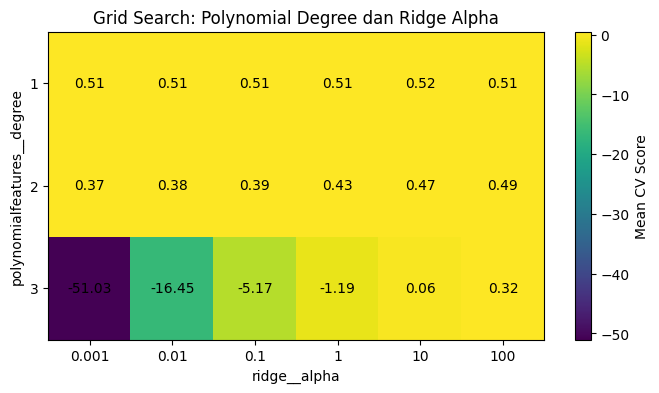

In [12]:
scores = grid_ridge.cv_results_["mean_test_score"].reshape(
    len(param_grid_ridge["polynomialfeatures__degree"]),
    len(param_grid_ridge["ridge__alpha"])
)

plt.figure(figsize=(8, 4))
plt.imshow(scores, aspect="auto")
plt.colorbar(label="Mean CV Score")
plt.xticks(
    range(len(param_grid_ridge["ridge__alpha"])),
    param_grid_ridge["ridge__alpha"]
)
plt.yticks(
    range(len(param_grid_ridge["polynomialfeatures__degree"])),
    param_grid_ridge["polynomialfeatures__degree"]
)
plt.xlabel("ridge__alpha")
plt.ylabel("polynomialfeatures__degree")
plt.title("Grid Search: Polynomial Degree dan Ridge Alpha")

for i in range(scores.shape[0]):
    for j in range(scores.shape[1]):
        plt.text(j, i, f"{scores[i, j]:.2f}", ha="center", va="center")

plt.show()

## Perbandingan Tanpa Polynomial Features

Untuk melihat apakah polynomial features benar-benar membantu, kita dapat membandingkan hasilnya dengan pipeline yang hanya menggunakan StandardScaler dan Ridge.

In [13]:
pipe_ridge_simple = make_pipeline(
    StandardScaler(),
    Ridge()
)

param_grid_simple = {
    "ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_simple = GridSearchCV(
    pipe_ridge_simple,
    param_grid_simple,
    cv=5
)

grid_simple.fit(X_train, y_train)

print("Best parameters tanpa polynomial:", grid_simple.best_params_)
print(f"Test score tanpa polynomial: {grid_simple.score(X_test, y_test):.2f}")
print(f"Test score dengan polynomial: {grid_ridge.score(X_test, y_test):.2f}")

Best parameters tanpa polynomial: {'ridge__alpha': 10}
Test score tanpa polynomial: 0.36
Test score dengan polynomial: 0.36


## Analisis Tuning Preprocessing

Pipeline memudahkan eksperimen karena preprocessing dan model dapat dituning dalam satu proses. Namun, semakin banyak parameter yang dicari, semakin banyak kombinasi model yang harus dilatih.

Karena itu, parameter grid sebaiknya dibuat cukup masuk akal. Grid yang terlalu besar dapat membuat proses training lama dan belum tentu memberikan peningkatan performa yang berarti.

## Grid Search untuk Memilih Model

Pipeline juga dapat digunakan untuk membandingkan beberapa model sekaligus. Contohnya, kita dapat membandingkan SVC dan Random Forest dalam satu `GridSearchCV`.

Karena SVC biasanya membutuhkan scaling, sedangkan Random Forest tidak terlalu membutuhkan scaling, preprocessing juga dapat ikut dimasukkan ke dalam parameter grid.

In [14]:
iris = load_iris()

X_train, X_test, y_train, y_test = train_test_split(
    iris.data,
    iris.target,
    random_state=0
)

pipe_model_selection = Pipeline([
    ("preprocessing", StandardScaler()),
    ("classifier", SVC())
])

param_grid_model_selection = [
    {
        "classifier": [SVC()],
        "preprocessing": [StandardScaler(), None],
        "classifier__C": [0.1, 1, 10],
        "classifier__gamma": [0.001, 0.01, 0.1, 1]
    },
    {
        "classifier": [RandomForestClassifier(n_estimators=100, random_state=0)],
        "preprocessing": [None],
        "classifier__max_features": [1, 2, 3]
    }
]

grid_model_selection = GridSearchCV(
    pipe_model_selection,
    param_grid_model_selection,
    cv=5
)

grid_model_selection.fit(X_train, y_train)

print("Best parameters:")
print(grid_model_selection.best_params_)
print(f"Best CV score: {grid_model_selection.best_score_:.2f}")
print(f"Test set score: {grid_model_selection.score(X_test, y_test):.2f}")

Best parameters:
{'classifier': SVC(), 'classifier__C': 10, 'classifier__gamma': 0.1, 'preprocessing': None}
Best CV score: 0.97
Test set score: 0.97


## Analisis Pemilihan Model dengan Pipeline

Dengan pendekatan ini, pipeline tidak hanya digunakan untuk memilih parameter, tetapi juga dapat memilih jenis model dan jenis preprocessing. Ini berguna saat belum yakin kombinasi mana yang paling baik.

Namun, pendekatan ini perlu digunakan secara hati-hati. Jika terlalu banyak model, preprocessing, dan parameter dicoba sekaligus, search space menjadi sangat besar. Proses training dapat memakan waktu lama dan berisiko overfitting terhadap validation process.

## Ringkasan Praktik Baik Pipeline

Beberapa praktik baik saat menggunakan pipeline:

- Masukkan semua preprocessing yang belajar dari data ke dalam pipeline.
- Gunakan pipeline bersama cross-validation dan GridSearchCV.
- Gunakan nama step yang jelas jika pipeline kompleks.
- Hindari preprocessing manual sebelum cross-validation.
- Jangan membuat grid search terlalu besar tanpa alasan.
- Evaluasi akhir tetap dilakukan pada test set yang terpisah.

## Kesimpulan Chapter

Chapter ini menjelaskan bahwa workflow machine learning sering terdiri dari beberapa tahap, bukan hanya satu model. Preprocessing seperti scaling, feature selection, polynomial features, dan PCA dapat sangat memengaruhi performa model. Jika dilakukan di luar cross-validation, preprocessing dapat menyebabkan data leakage dan menghasilkan evaluasi yang terlalu optimis.

`Pipeline` menjadi solusi karena mampu menggabungkan preprocessing dan model dalam satu estimator. Pipeline juga dapat digunakan bersama `GridSearchCV` untuk mencari parameter terbaik dari preprocessing dan model secara bersamaan. Selain membuat kode lebih rapi, pipeline membantu memastikan proses evaluasi dilakukan dengan benar.

Secara keseluruhan, pipeline adalah alat penting dalam machine learning praktis karena membuat workflow lebih aman, terstruktur, dan mudah dieksperimenkan.